# Dimer QME:  The unitary part

We already learned the quantum master equation for general cases in {numref}`ch:openqm-qme`.  Here we provide the explicit expression for a dimer.

## Free Hamiltonian and degeneracy

Each emitter is model as TLS as defined in {numref}`ssec:TLS`.  The product basis for the dimer is given by {eq}`eq:product-basis-2`.  The explicit expression of spin operators {eq}`eq:sigma-N` for $N=2$ is

$$
\sigma_{1}^{\mu} = \sigma^{\mu} \otimes I, \qquad \sigma_{2}^{\mu} = I \otimes \sigma^{\mu} , \qquad \mu = x,y,z, \pm.
$$


Using these operators, the free Hamiltonian of a dimer is given by

$$
H_{0} = \frac{\omega_{0}}{2} \left(\sigma^{z}_{1} + \sigma^{z}_{2}\right).
$$

It has energy eigen values $E_{ee}=\omega_{0}$, $E_{ge}=E_{eg}=0$, and $E_{gg}=-\omega_{0}$.  The product basis, $|gg\rangle$, $|ge\rangle$, $|eg\rangle$, and $|ee\rangle$ are the corresponding eigen vectors, respectively.  


````{admonition}  **QuTiP Note**
:class: note
:name: qutip:tensor product

To construct a new operator for the dimer, we need to use tensor product and an identiy operator.

* Identity operator in 2D Hilbert space :  `qeye(2)`
* Tensor product of A and B:  `tensor(A,B)`

Example:  Define $\sigma^{z}_{1}$ and $\sigma^{z}_{2}$ and store them in a list

```
sz = [tensor(sigmaz(),qeye(2)), tensor(qeye(2),sigmaz()]
```

````

## Alternative basis set

Notice the degeneracy in the energy spectrum. The energy eigen vectors are not unique in this case. Any linear combination of $|ge\rangle$ and $∣eg\rangle$ is an energy eigen vector.  Taking this freedom, another basis set is often used:

$$
|e\rangle = |ee\rangle, \quad |s\rangle = \frac{1}{\sqrt{2}}\left(|eg\rangle+|ge\rangle\right), \qquad |a\rangle = \frac{1}{\sqrt{2}}\left(|eg\rangle-|ge\rangle\right), \qquad |g\rangle = |gg\rangle.
$$(eq:sa-basis)

which can be also expressed in the angular momentum eigen vectors $|J,M\rangle$.

The triplet states are

$$
|1,1\rangle = |e\rangle, \qquad |1,0\rangle = |s\rangle, \qquad |1,-1\rangle = |g\rangle
$$(eq:triplet)

and the single state is

$$
|0,0\rangle = |a\rangle.
$$(eq:singlet)

## Dipole-diploe coupling

The diople-dipole coupling for $N=2$ is

$$
H_\text{dd} = \Omega_{12} \left(\sigma^{+}_{1}\sigma^{-}_{2} + \sigma^{+}_{2}\sigma^{-}_{1}\right).
$$(eq:H_dd-2)

and the coefficient is 

$$
\Omega_{12} = - \frac{3\gamma_0}{4} \left[ \left(1 - \cos^2 \theta_{12}\right) \frac{\cos(k_0 r_{12})}{k_0 r_{12}}
+ \left(1-3 \cos^2 \theta_{12} \right) \left (\frac{\sin(k_0 r_{12})}{(k_0 r_{12})^2} -  \frac{\cos(k_0 r_{12})}{(k_0 r_{12})^3} \right) \right]
$$(eq:omega_12)

where $\theta_{12}$ is the angle betwen $\mathbf{d}$ and $\mathbf{r}_{12}$ and $\gamma^{0}$ is the rate of spontaneous emission.

The main role of this coupling is to lift the degeneracy in the free Hamiltonian. Digonalizing $H_{0}+H_{dd}$, we find the basis vectors {eq}`eq:sa-basis` are the energy eigenvectors and The corresponding energy eigen values are $E_{e}=\omega_{0}$, $E_{s}=\Omega_{12}$, $E_{a}=-\Omega_{12}$ and $E_{g}=-\omega_{0}$, respectively. 

There is a big problem with this model. As $r_{12} \rightarrow 0$, the coefficient $\Omega_{12}$ diverges.
(See the plot below.)  The origin of the divergence is known and there have been various attempts to mitigate the divergence. The fact that the actual shift of the energy observed by experiments is very minute ($\Omega_{12} \sim 0.01 \omega_{0}$) and thus the dipole-dipole coupling is not expected to play any significant role.  In our model, $H_{dd}$ is included just for completeness but we do not use the formula for {eq}`eq:omega_12`. Rather we consider the coefficient as a parameter ($\Omega_{12} < \omega_{0}$).  For $r_{12}/\lambda_{0} \gg 1$, we assume $\Omega_{12}=0$.   

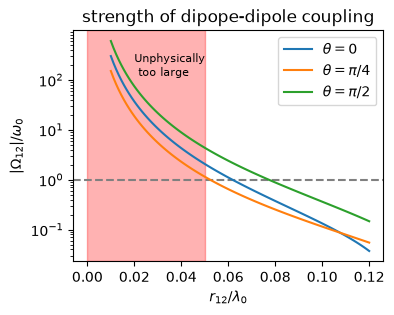

In [21]:
import numpy as np
import matplotlib.pyplot as plt

omega0=1.0
gamma0=0.1

def f(x,theta):
    y=(1-np.cos(theta)**2)*np.cos(x)/x + (1-3*np.sin(theta)**2)*(np.sin(x)/x**2 - np.cos(x)/x**3)
    return -y*3/4 *gamma0/omega0

x0=np.linspace(0.01,0.12,100)
x1=2*np.pi*x0
y1 = f(x1,0)
y2 = f(x1,np.pi/4)
y3 = f(x1,np.pi/2)
plt.figure(figsize=(4,3))
plt.title("strength of dipope-dipole coupling")
plt.axhline(y=1,color='grey',ls='--')
plt.semilogy(x0,abs(y1),label=r"$\theta=0$")
plt.semilogy(x0,abs(y2),label=r"$\theta=\pi/4$")
plt.semilogy(x0,abs(y3),label=r"$\theta=\pi/2$")
plt.xlabel(r"$r_{12}/\lambda_{0}$")
plt.ylabel(r"$|\Omega_{12}|/\omega_{0}$")
plt.legend(loc=1)
plt.axvspan(0, 0.05, color='red', alpha=0.3)
plt.text(0.02,120,"Unphysically\n too large",size=8)
plt.show()